In [43]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../src")
from utils import apply_theme_and_set_plot_params

COMM_AREA_AGG_FE_DF = Path("../data/processed/community_areas_agg_fe_df.parquet")
comm_area_agg_fe_df = pd.read_parquet(COMM_AREA_AGG_FE_DF)

In [44]:
# look at the df
comm_area_agg_fe_df.head()

,COMMUNITY_AREA_NUMBER,COMMUNITY_AREA_NAME,PERCENT_OF_HOUSING_CROWDED,PERCENT_HOUSEHOLDS_BELOW_POVERTY,PERCENT_AGED_16__UNEMPLOYED,PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA,PERCENT_AGED_UNDER_18_OR_OVER_64,PER_CAPITA_INCOME,HARDSHIP_INDEX,UniqueNetworkManagersCount,...,MeanEnvironmentScore,MeanInstructionScore,MeanStudentAttendance,TotalCrimes,UniqueCrimeCategories,ArrestsCount,SchoolQualityScore,CrimesPerIncome,CrimesPerCrimeCategory,ArrestsPerCrime
0,1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0,2,...,43.250000,36.750000,93.050000,6.0,6.0,3.0,39.850000,0.000251,1.0,0.500000
1,2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0,2,...,58.444444,56.555556,94.922222,7.0,5.0,2.0,60.448413,0.000304,1.4,0.285714
2,3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0,2,...,59.000000,58.000000,94.542857,4.0,1.0,4.0,54.375000,0.000112,4.0,1.000000
3,4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0,2,...,46.600000,44.600000,92.840000,3.0,3.0,1.0,53.350000,0.000080,1.0,0.333333
4,5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0,2,...,65.500000,51.166667,95.542857,4.0,4.0,2.0,71.375000,0.000070,1.0,0.500000


In [45]:
# shape
comm_area_agg_fe_df.shape

(77, 22)

In [46]:
# info
comm_area_agg_fe_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 22 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   COMMUNITY_AREA_NUMBER                         77 non-null     float64 
 1   COMMUNITY_AREA_NAME                           77 non-null     category
 2   PERCENT_OF_HOUSING_CROWDED                    77 non-null     float64 
 3   PERCENT_HOUSEHOLDS_BELOW_POVERTY              77 non-null     float64 
 4   PERCENT_AGED_16__UNEMPLOYED                   77 non-null     float64 
 5   PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA  77 non-null     float64 
 6   PERCENT_AGED_UNDER_18_OR_OVER_64              77 non-null     float64 
 7   PER_CAPITA_INCOME                             77 non-null     int64   
 8   HARDSHIP_INDEX                                77 non-null     float64 
 9   UniqueNetworkManagersCount                    77 non-null     int64

In [47]:
# check NaN values
comm_area_agg_fe_df.isna().sum()

COMMUNITY_AREA_NUMBER                           0
COMMUNITY_AREA_NAME                             0
PERCENT_OF_HOUSING_CROWDED                      0
PERCENT_HOUSEHOLDS_BELOW_POVERTY                0
PERCENT_AGED_16__UNEMPLOYED                     0
PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA    0
PERCENT_AGED_UNDER_18_OR_OVER_64                0
PER_CAPITA_INCOME                               0
HARDSHIP_INDEX                                  0
UniqueNetworkManagersCount                      0
MeanSafetyScore                                 0
MeanFamilyInvolvementScore                      0
MeanEnvironmentScore                            0
MeanInstructionScore                            0
MeanStudentAttendance                           0
TotalCrimes                                     0
UniqueCrimeCategories                           0
ArrestsCount                                    0
SchoolQualityScore                              0
CrimesPerIncome                                 0


## Exploratory Data Analysis

In [48]:
# basic statistics
comm_area_agg_fe_df.describe(include="number").round(2)

,COMMUNITY_AREA_NUMBER,PERCENT_OF_HOUSING_CROWDED,PERCENT_HOUSEHOLDS_BELOW_POVERTY,PERCENT_AGED_16__UNEMPLOYED,PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA,PERCENT_AGED_UNDER_18_OR_OVER_64,PER_CAPITA_INCOME,HARDSHIP_INDEX,UniqueNetworkManagersCount,MeanSafetyScore,...,MeanEnvironmentScore,MeanInstructionScore,MeanStudentAttendance,TotalCrimes,UniqueCrimeCategories,ArrestsCount,SchoolQualityScore,CrimesPerIncome,CrimesPerCrimeCategory,ArrestsPerCrime
count,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,...,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.0,77.00,77.00
mean,39.00,4.92,21.77,15.37,20.34,35.75,25563.17,49.51,1.87,51.99,...,47.56,47.72,92.55,6.36,4.18,1.86,49.74,0.0,1.32,0.25
std,22.37,3.68,11.53,7.54,11.82,7.33,15293.10,28.69,0.66,16.56,...,9.28,9.39,2.73,6.45,3.06,2.11,9.90,0.0,0.67,0.23
min,1.00,0.30,3.30,4.70,2.50,13.50,8201.00,1.00,1.00,25.40,...,12.00,1.00,84.15,0.00,0.00,0.00,26.55,0.0,0.00,0.00
25%,20.00,2.30,13.20,9.20,11.80,32.00,15754.00,25.00,1.00,39.67,...,42.00,42.43,90.85,2.00,2.00,0.00,43.40,0.0,1.00,0.00
50%,39.00,3.80,18.90,13.90,18.50,38.10,21323.00,50.00,2.00,49.73,...,47.30,49.22,92.92,5.00,4.00,1.00,48.81,0.0,1.29,0.23
75%,58.00,6.80,29.20,20.00,26.60,40.50,28887.00,74.00,2.00,59.83,...,53.00,53.00,94.61,9.00,6.00,3.00,54.15,0.0,1.57,0.40
max,77.00,15.80,56.50,35.90,54.80,51.50,88669.00,98.00,3.00,99.00,...,68.00,67.00,96.50,43.00,14.00,11.00,80.46,0.0,4.00,1.00


In [49]:
# set theme and plot params
apply_theme_and_set_plot_params()

### Skewness Checking

We can check numerical variables that will need to be log-transformed later in clustering

In [50]:
skewness = comm_area_agg_fe_df.select_dtypes(include="number").skew().sort_values(ascending=False)
skewness

TotalCrimes                                     2.832699
CrimesPerIncome                                 2.808662
PER_CAPITA_INCOME                               1.896166
ArrestsCount                                    1.744101
PERCENT_OF_HOUSING_CROWDED                      1.230923
ArrestsPerCrime                                 0.867678
MeanFamilyInvolvementScore                      0.858990
PERCENT_HOUSEHOLDS_BELOW_POVERTY                0.813058
PERCENT_AGED_16__UNEMPLOYED                     0.735354
MeanSafetyScore                                 0.725053
PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA    0.717884
CrimesPerCrimeCategory                          0.706055
SchoolQualityScore                              0.696872
UniqueCrimeCategories                           0.655785
UniqueNetworkManagersCount                      0.139250
COMMUNITY_AREA_NUMBER                           0.000000
HARDSHIP_INDEX                                 -0.000697
MeanEnvironmentScore           

### Numerical Feature Analysis

Are total crimes normally distributed? Are there outliers?

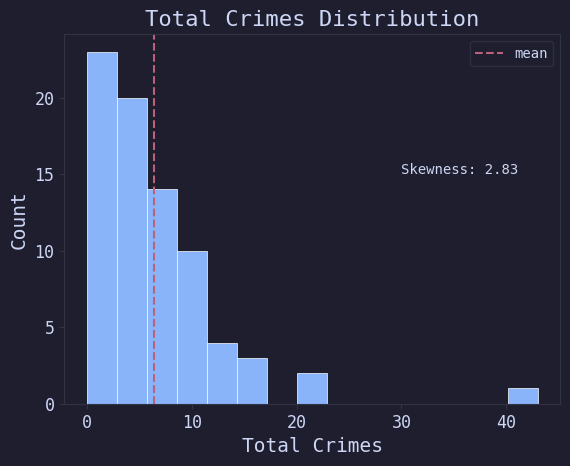

In [51]:
total_crimes_stats = comm_area_agg_fe_df.TotalCrimes.agg(["mean", "skew"]).round(2)

plt.hist(comm_area_agg_fe_df.TotalCrimes, bins=15, edgecolor="white", linewidth=0.5)
plt.axvline(total_crimes_stats.iloc[0], color="#ba617c", linestyle="--", label="mean")
plt.title("Total Crimes Distribution")
plt.xlabel("Total Crimes")
plt.ylabel("Count")
plt.text(x=30, y=15, s=f"Skewness: {total_crimes_stats.iloc[1]}")
plt.legend()
plt.show()

Are arrests common?

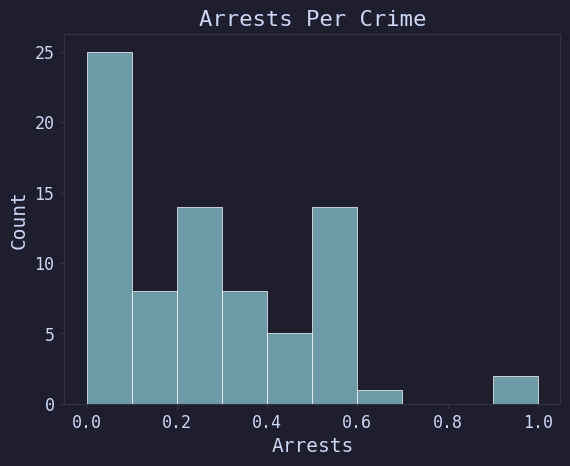

In [52]:
plt.hist(comm_area_agg_fe_df.ArrestsPerCrime, edgecolor="white", color="#6c9ba7", linewidth=0.5)
plt.xlabel("Arrests")
plt.ylabel("Count")
plt.title("Arrests Per Crime")
plt.show()

Are most schools safe, on average? What about family involvement, environment and instruction?

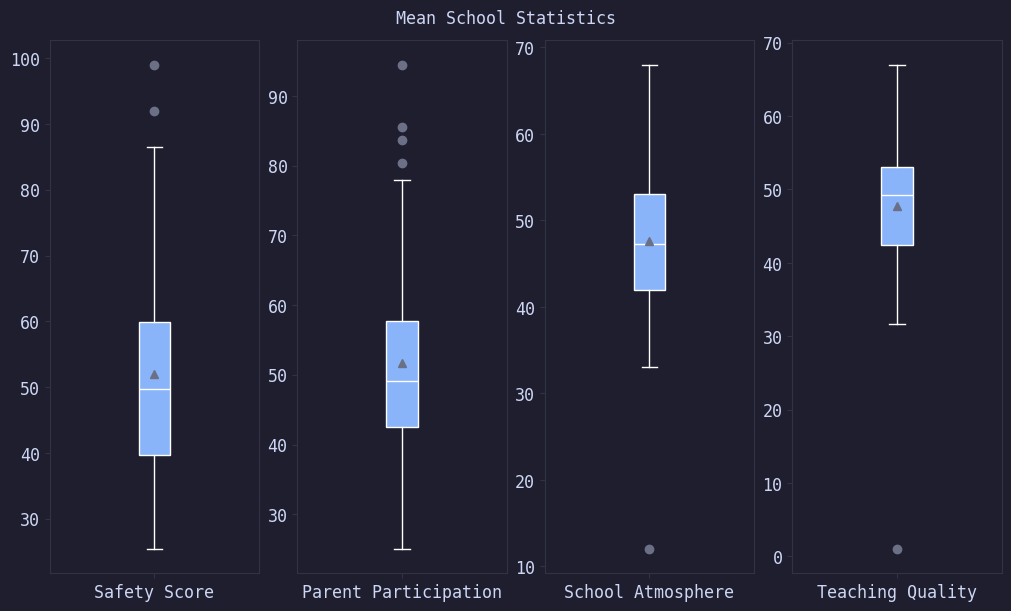

In [53]:
schools_data = [comm_area_agg_fe_df.MeanSafetyScore, comm_area_agg_fe_df.MeanFamilyInvolvementScore,
                comm_area_agg_fe_df.MeanEnvironmentScore, comm_area_agg_fe_df.MeanInstructionScore]
schools_scores = ["Safety Score", "Parent Participation", "School Atmosphere", "Teaching Quality"]
fig, axes = plt.subplots(nrows=1, ncols=4, constrained_layout=True, figsize=(10, 6))

boxplot_style = {
    'whiskerprops': {'color': 'white'},
    'medianprops': {'color': 'white'},
    'capprops': {'color': 'white'},
    'boxprops': {'edgecolor': 'white'}
}

for i in range(len(schools_data)):
    axes[i].boxplot([schools_data[i]], patch_artist=True, tick_labels=[schools_scores[i]], showmeans=True, **boxplot_style)

plt.suptitle("Mean School Statistics")
plt.show()

### Community Area Analysis

What are the top 10 community areas regarding school quality, on average?

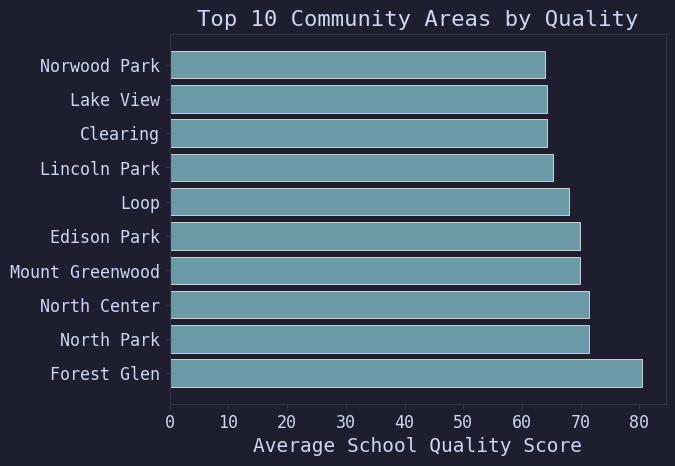

In [54]:
top_ten_avg_school_qual = comm_area_agg_fe_df[["COMMUNITY_AREA_NAME", "SchoolQualityScore"]].sort_values(by="SchoolQualityScore", ascending=False).head(10)

plt.barh(top_ten_avg_school_qual["COMMUNITY_AREA_NAME"], top_ten_avg_school_qual["SchoolQualityScore"], edgecolor="white", color="#6c9ba7", linewidth=0.5)
plt.title("Top 10 Community Areas by Quality")
plt.xlabel("Average School Quality Score")
plt.show()

Do some community areas have lower hardship indeces than others?

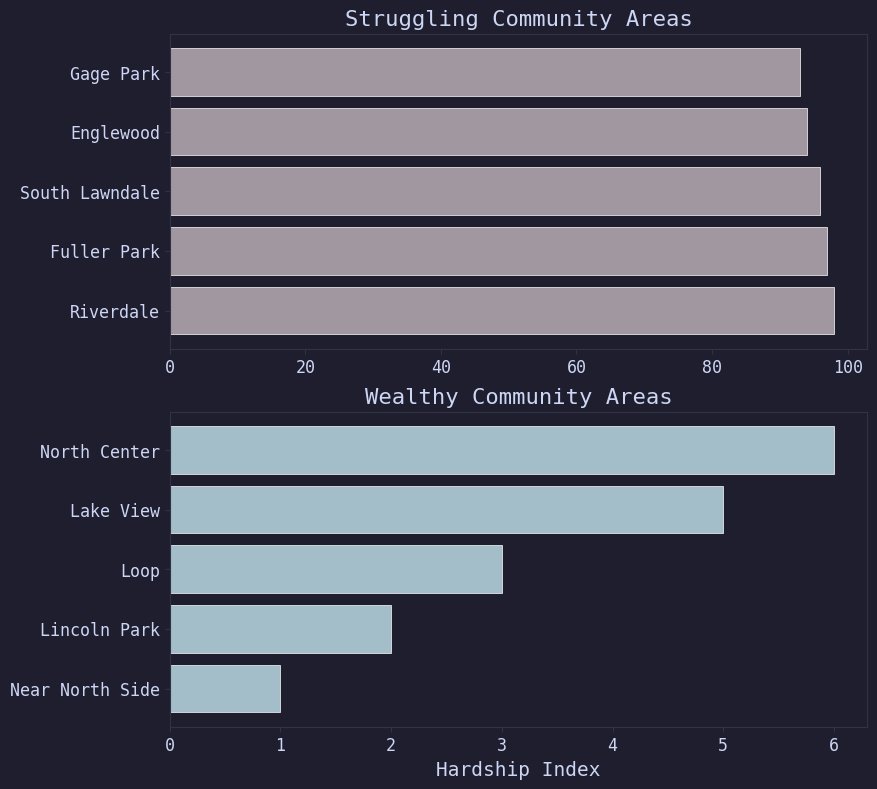

In [55]:
comm_area_hardship_indeces = comm_area_agg_fe_df[["COMMUNITY_AREA_NAME", "HARDSHIP_INDEX"]].sort_values(by="HARDSHIP_INDEX", ascending=False)
struggling_comm_areas = comm_area_hardship_indeces.nlargest(5, "HARDSHIP_INDEX")
wealthy_comm_areas = comm_area_hardship_indeces.nsmallest(5, "HARDSHIP_INDEX")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(9, 9))

axes[0].barh(struggling_comm_areas["COMMUNITY_AREA_NAME"], struggling_comm_areas["HARDSHIP_INDEX"], edgecolor="white", color="#a097a1", linewidth=0.5)
axes[0].set_title("Struggling Community Areas")

axes[1].barh(wealthy_comm_areas["COMMUNITY_AREA_NAME"], wealthy_comm_areas["HARDSHIP_INDEX"], edgecolor="white", color="#a3bdc9", linewidth=0.5)
axes[1].set_title("Wealthy Community Areas")
axes[1].set_xlabel("Hardship Index")
plt.show()

Do high hardship areas have more crimes?

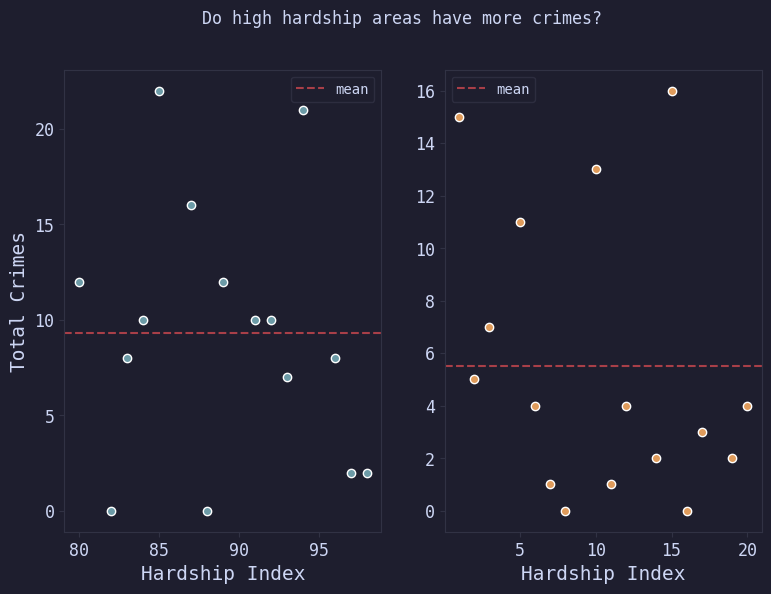

In [56]:
high_hardship_df = comm_area_agg_fe_df[comm_area_agg_fe_df.HARDSHIP_INDEX >= 80]
low_hardship_df = comm_area_agg_fe_df[comm_area_agg_fe_df.HARDSHIP_INDEX <= 20]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 6))

axes[0].scatter(high_hardship_df.HARDSHIP_INDEX, high_hardship_df.TotalCrimes, edgecolor="white", color="#6c9ba7")
axes[0].axhline(high_hardship_df.TotalCrimes.mean(), linestyle="--", color="#a83f48", label="mean")
axes[0].set_xlabel("Hardship Index")
axes[0].set_ylabel("Total Crimes")
axes[0].legend()

axes[1].scatter(low_hardship_df.HARDSHIP_INDEX, low_hardship_df.TotalCrimes, edgecolor="white", color="#df9b5b")
axes[1].axhline(low_hardship_df.TotalCrimes.mean(), linestyle="--", color="#a83f48", label="mean")
axes[1].set_xlabel("Hardship Index")
axes[1].legend()

plt.suptitle("Do high hardship areas have more crimes?")
plt.show()

Do low-income areas have weaker teaching?

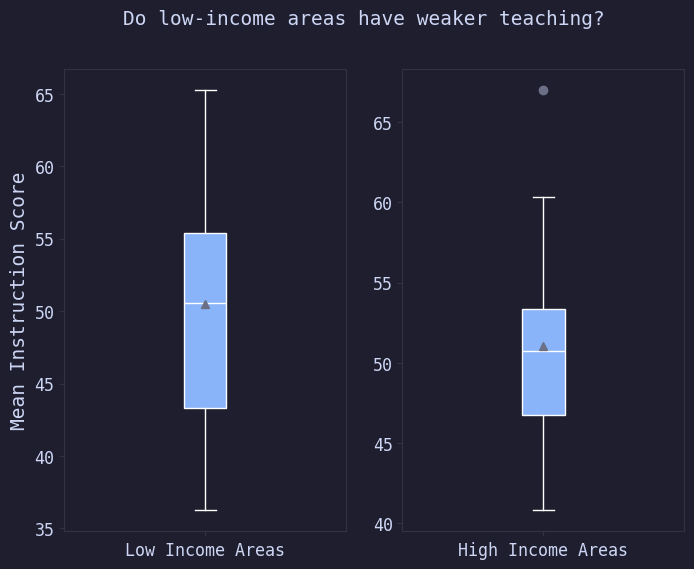

In [57]:
# I use quantiles to be more data-driven instead of defining absolute values such as >= / <= 40k
low_income_areas_df = comm_area_agg_fe_df[comm_area_agg_fe_df.PER_CAPITA_INCOME < comm_area_agg_fe_df.PER_CAPITA_INCOME.quantile(q=0.2)]
high_income_areas_df = comm_area_agg_fe_df[comm_area_agg_fe_df.PER_CAPITA_INCOME > comm_area_agg_fe_df.PER_CAPITA_INCOME.quantile(q=0.8)]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 6))

axes[0].boxplot([low_income_areas_df.MeanInstructionScore], patch_artist=True, tick_labels=["Low Income Areas"], showmeans=True, **boxplot_style)
axes[0].set_ylabel("Mean Instruction Score")

axes[1].boxplot([high_income_areas_df.MeanInstructionScore], patch_artist=True, tick_labels=["High Income Areas"], showmeans=True, **boxplot_style)

plt.suptitle("Do low-income areas have weaker teaching?", fontsize=14)
plt.show()

### Correlation Analysis

Which are the features that are most correlated?

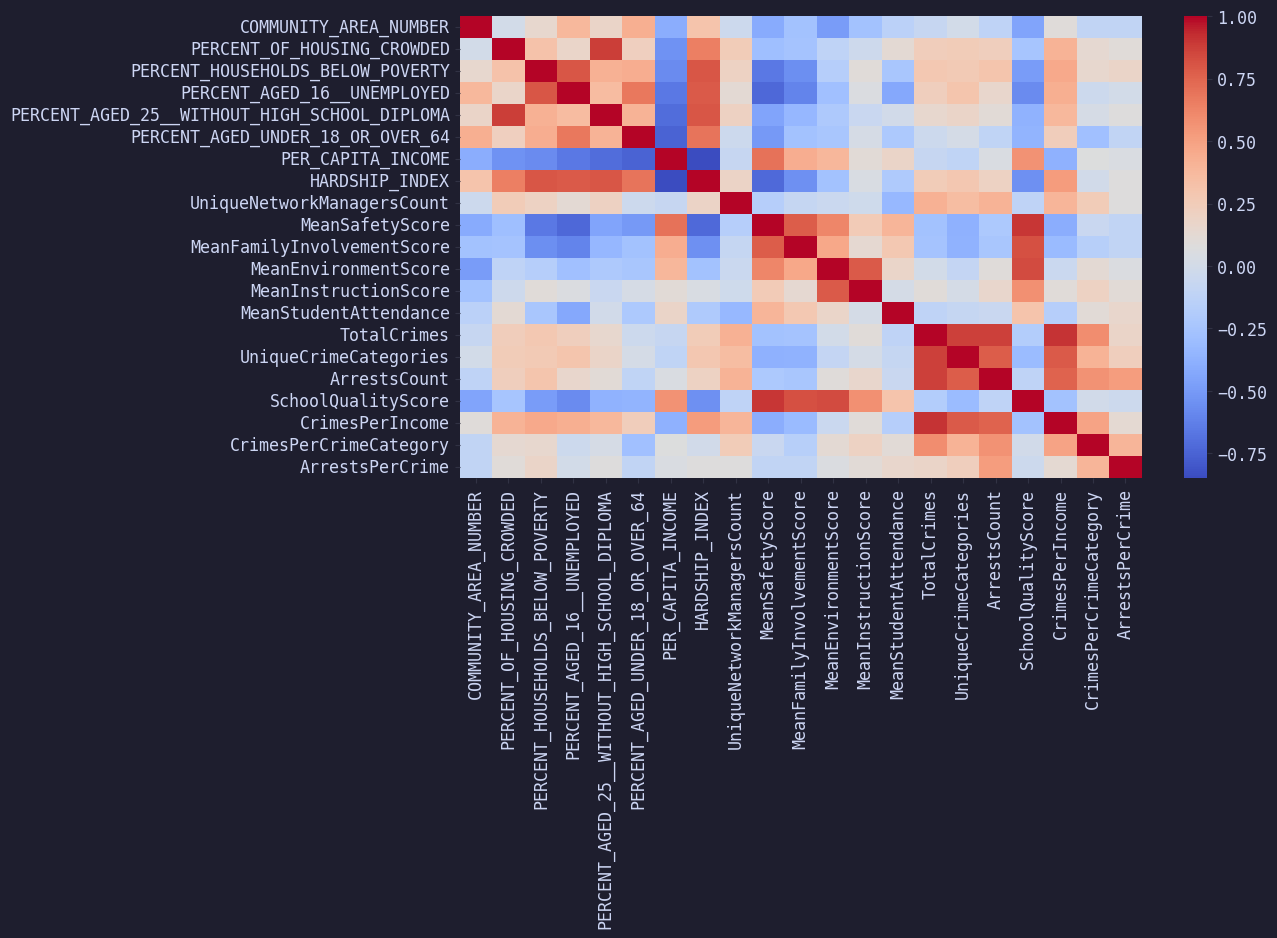

In [58]:
num_corrs = comm_area_agg_fe_df.corr(numeric_only=True).round(2)

plt.figure(figsize=(11, 6))
sns.heatmap(num_corrs, cmap="coolwarm", annot_kws={"fontsize": 8})
plt.show()

Which features are the most correlated with Hardship Index?

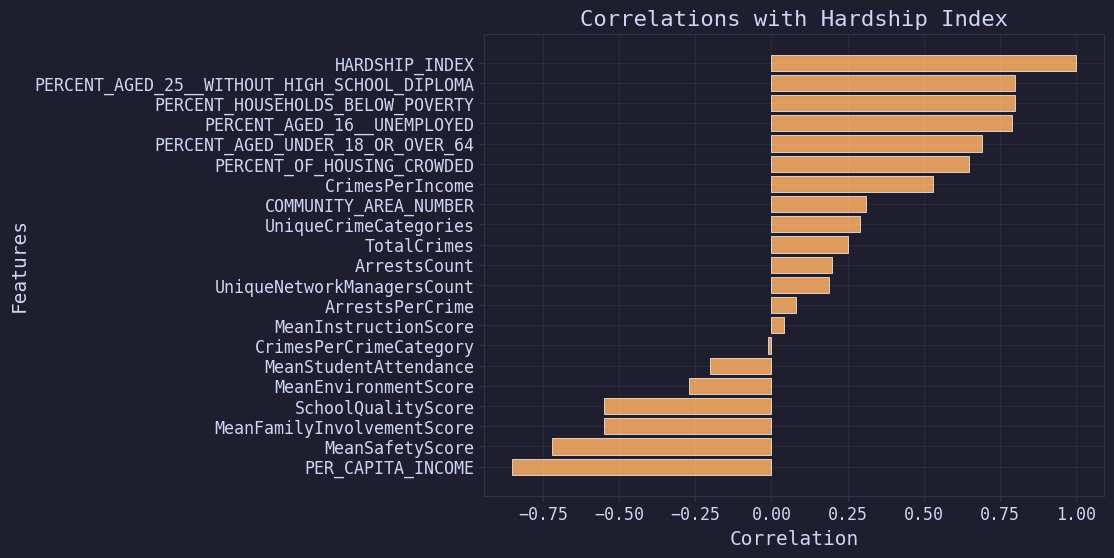

In [59]:
hardship_index_corr = num_corrs["HARDSHIP_INDEX"].sort_values()

plt.figure(figsize=(8, 6))
plt.barh(hardship_index_corr.index, hardship_index_corr.values, edgecolor="white", color="#df9b5b", linewidth=0.5)
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.title("Correlations with Hardship Index")
plt.grid(alpha=0.05, color="white")
plt.show()

Do safer community areas generally have less crimes?

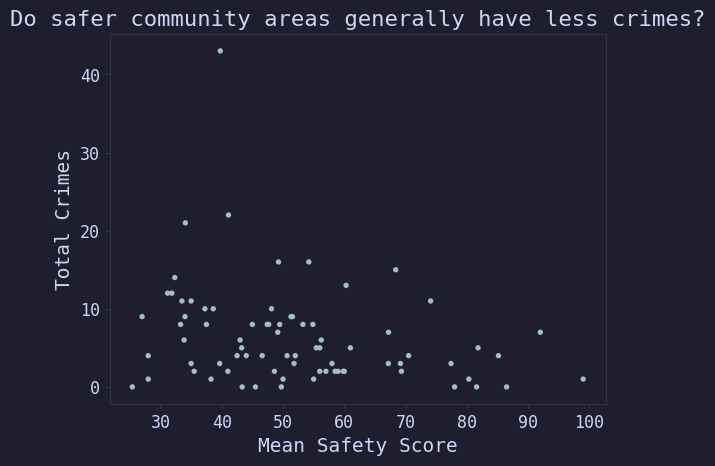

In [60]:
plt.scatter(comm_area_agg_fe_df.MeanSafetyScore, comm_area_agg_fe_df.TotalCrimes, color="#a3bdc9", edgecolor="none", s=15)
plt.xlabel("Mean Safety Score")
plt.ylabel("Total Crimes")
plt.title("Do safer community areas generally have less crimes?")
plt.show()

Are arrests common in areas that have a high percentage of poor households?

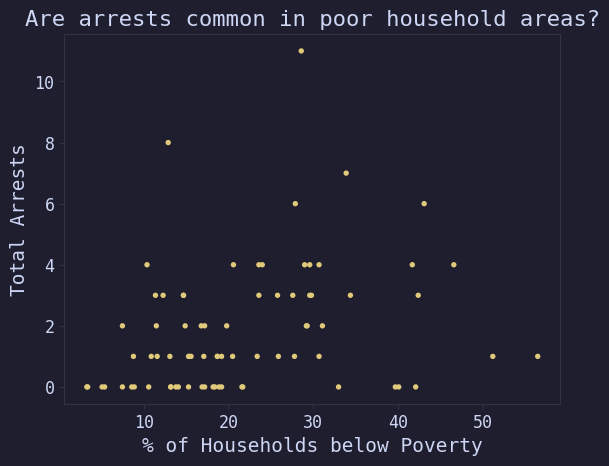

In [61]:
plt.scatter(comm_area_agg_fe_df.PERCENT_HOUSEHOLDS_BELOW_POVERTY, comm_area_agg_fe_df.ArrestsCount, color="#e1c97a", edgecolor="none", s=15)
plt.xlabel("% of Households below Poverty")
plt.ylabel("Total Arrests")
plt.title("Are arrests common in poor household areas?")
plt.show()

### Outlier Detection

Are there many outliers among crimes?

In [62]:
Q1_crimes = comm_area_agg_fe_df.TotalCrimes.quantile(0.25)
Q3_crimes = comm_area_agg_fe_df.TotalCrimes.quantile(0.75)

IQR = Q3_crimes - Q1_crimes
outliers = ((comm_area_agg_fe_df.TotalCrimes < Q1_crimes - 1.5 * IQR) | (comm_area_agg_fe_df.TotalCrimes > Q3_crimes + 1.5 * IQR)).sum()

print(f"Crime Outliers' Count: {outliers}")

Crime Outliers' Count: 3


# Exploratory Data Analysis Conclusions

Skewness:
-	The most positively skewed variables are TotalCrimes, CrimesPerIncome, PER_CAPITA_INCOME, and ArrestsCount. Log transformation will be considered during preprocessing to reduce skewness and the influence of extreme values on distance-based clustering.
Numerical Feature Analysis:
-	TotalCrimes is strongly positively skewed (skewness = 2.83), indicating that a small number of community areas experience substantially more crimes than the majority. The IQR analysis also identified a small number of outlying observations.
-	Considering arrests per crime, not every crime has an equal number of arrests, according to the data. Most community areas have an ArrestsPerCrime ratio below 0.6, indicating that fewer than 60% of recorded crimes result in an arrest on average.
-	Average safety score and parent participation distributions include a few outliers, suggesting that in some communities safety is higher than usual and parents are more present.
Community Area Analysis:
-	Struggling community areas are represented by Riverdale, Fuller Park and South Lawndale, as suggested by the high hardship index above 90. The wealthiest ones are Near North Side, Lincoln Park and Loop.
-	High-hardship community areas exhibit higher average crime counts (9.3) than low-hardship areas (5.5), suggesting a positive association between hardship and crime.
-	No substantial difference in teaching quality was observed between the lowest- and highest-income community areas.
Correlation Analysis:
-	Features most correlated with hardship index are PERCENT_AGED_25_WITHOUT_HIGH_SCHOOL_DIPLOMA, PERCENT_HOUSEHOLDS_BELOW_POVERTY, PERCENT_AGED_16_UNEMPLOYED, PERCENT_AGED_UNDER_18_OR_OVER_64 and PERCENT_OF_HOUSING_CROWDED. Since the hardship index is derived from socioeconomic indicators, these variables may introduce redundancy during clustering. Feature selection will therefore consider whether to retain the composite hardship index, the individual indicators, or both to avoid overweighting the same underlying concept.

Preprocessing Implications
-	Several variables exhibit positive skewness and may benefit from log transformation. 
-	Features are measured on different scales (e.g., income, percentages, crime counts, and school scores), so standardization will be performed before clustering. 
-	Highly correlated variables will be reviewed to reduce redundancy and improve cluster interpretability.